In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
model = load_model("../models/classification_model.keras", compile=False)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

test_dir = "../data/raw/Testing"

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ✅ SAME as training
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [12]:
loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 897ms/step - accuracy: 0.8650 - loss: 0.4173
Test Accuracy: 0.8650000095367432


In [13]:
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 781ms/step


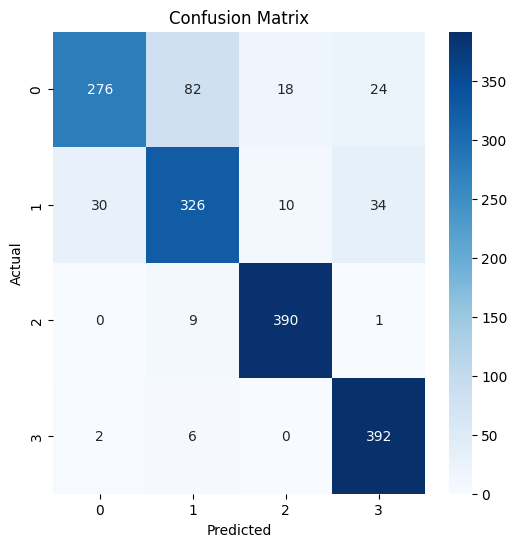

In [14]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.90      0.69      0.78       400
  meningioma       0.77      0.81      0.79       400
     notumor       0.93      0.97      0.95       400
   pituitary       0.87      0.98      0.92       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600

